In [ ]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math as mm
import opstool as opst
import time as tt

In [16]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [17]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (92864245707)>


In [18]:
###########################################################
# Starting a new model
###########################################################

Analysis_Name = "QZLiq_Behaviour"

# wipe the model
ops.wipe()
# spring nodes created with 2 dim, 2 dof
ops.model('basic', '-ndm', 2, '-ndf', 2) 

# define nodes and fixities
ops.node(1,0.0,0.0);
ops.fix(1,0,0);
ops.node(2,0.0,0.0);
ops.fix(2,1,1);

# Mean Stress time-series
MeanStress=np.array([1.000,0.990,0.980,0.970,0.960,0.950,0.940,0.931,0.921,0.911,0.902,0.892,0.882,0.873,0.864,0.854,0.845,0.836,0.826,0.817,0.808,0.799,0.790,0.781,0.772,0.763,0.755,0.746,0.737,0.729,0.720,0.711,0.703,0.694,0.686,0.678,0.669,0.661,0.653,0.645,0.637,0.629,0.621,0.613,0.605,0.597,0.589,0.582,0.574,0.566,0.559,0.551,0.544,0.536,0.529,0.522,0.514,0.507,0.500,0.493,0.486,0.479,0.472,0.465,0.458,0.451,0.444,0.438,0.431,0.424,0.418,0.357,0.394,0.411,0.400,0.359,0.352,0.386,0.388,0.359,0.301,0.354,0.371,0.356,0.304,0.311,0.349,0.348,0.311,0.256,0.317,0.335,0.313,0.249,0.276,0.314,0.310,0.264,0.221,0.285,0.300,0.273,0.196,0.245,0.283,0.274,0.218,0.192,0.257,0.269,0.233,0.143,0.219,0.255,0.240,0.173,0.168,0.231,0.239,0.195,0.104,0.196,0.229,0.208,0.130,0.148,0.209,0.212,0.159,0.082,0.177,0.206,0.177,0.087,0.132,0.189,0.186,0.124,0.069,0.161,0.185,0.149,0.047,0.120,0.172,0.163,0.090,0.061,0.148,0.166,0.122,0.008,0.111,0.158,0.141,0.059,0.057,0.138,0.149,0.097,0.000,0.105,0.146,0.122,0.029,0.055,0.130,0.135,0.073,0.000,0.101,0.136,0.104,0.004,0.057,0.125,0.122,0.052,0.003,0.101,0.128,0.089,0.000,0.062,0.122,0.112,0.033,0.005,0.102,0.123,0.075,0.000,0.068,0.121,0.104,0.016,0.018,0.106,0.119,0.064])
MNS_Time  =np.linspace(0,30.0,len(MeanStress));
seriesTag =1;
ops.timeSeries('Path', seriesTag, '-time', *MNS_Time, '-values', *MeanStress, '-factor', 1.0);

# p-y liq
matTag=1;
soilType = 2; #soilType = 1 Backbone of p-y curve approximates Matlock (1970) soft clay relation. soilType = 2 Backbone of p-y curve approximates API (1993) sand relation.
pult = 1.0; #Ultimate capacity of the p-y material.
y50 = 0.0001; #Displacement at which 50% of pult is mobilized in monotonic loading.
Cd = 0.3; #Variable that sets the drag resistance within a fully-mobilized gap as Cd*pult.
c = 0.0; #The viscous damping term (dashpot) on the far-field (elastic) component of the displacement rate (velocity).
pRes = 0.1; #sets the minimum (or residual) peak resistance that the material retains as the adjacent solid soil elements liquefy
ops.uniaxialMaterial('PyLiq1', matTag, soilType, pult, y50, Cd,c,pRes,'-timeSeries', seriesTag);

# q-z liq
matTag=2;
qzType = 2; #qzType = 1 Backbone of q-z curve approximates Reese and O'Neill's (1987) relation for drilled shafts in clay. qzType = 2 Backbone of q-z curve approximates Vijayvergiya's (1977) relation for piles in sand.
qult = 100.0; #Ultimate capacity of the q-z material.
z50 = 0.0001; #Displacement at which 50% of qult is mobilized in monotonic loading.
suction = 0.0; #Uplift resistance is equal to suction*qult. Default = 0.0. The value of suction must be 0.0 to 0.1.*
c = 0.0; #The viscous damping term (dashpot) on the far-field (elastic) component of the displacement rate (velocity).
alpha = 0.55; # 
ops.uniaxialMaterial('QzLiq1', matTag, qzType, qult, z50, suction, c, alpha, '-timeSeries', seriesTag);

# zero-length element
eleTag = 1; node1=1; node2=2;
ops.element('zeroLength', eleTag, node1, node2, '-mat', 1,  '-dir', 1);
eleTag = 2; node1=1; node2=2;
ops.element('zeroLength', eleTag, node1, node2, '-mat', 2,  '-dir', 2);

# update the materials
ops.updateMaterialStage('-material',1,'-stage',1);
ops.updateMaterialStage('-material',2,'-stage',1);

# record element
ops.recorder('Element', '-file', 'QZ1_Liq.txt','-time','-ele', 2, 'force')

# record nodes
ops.recorder('Node', '-file', 'Node_Disp_Liq.txt','-time', '-node', 1, '-dof',2, 'disp')

Movement=np.array([0.000,0.006,0.011,0.015,0.018,0.020,0.020,0.018,0.015,0.011,0.006,0.000,-0.005,-0.011,-0.015,-0.018,-0.020,-0.020,-0.018,-0.015,-0.011,-0.006,-0.001,0.005,0.010,0.015,0.018,0.020,0.020,0.019,0.016,0.012,0.006,0.001,-0.005,-0.010,-0.014,-0.018,-0.020,-0.020,-0.019,-0.016,-0.012,-0.007,-0.001,0.004,0.010,0.014,0.018,0.020,0.020,0.019,0.016,0.012,0.007,0.001,-0.004,-0.009,-0.014,-0.017,-0.019,-0.020,-0.019,-0.016,-0.012,-0.007,-0.002,0.004,0.009,0.014,0.017,0.019,0.020,0.019,0.016,0.012,0.008,0.002,-0.004,-0.009,-0.014,-0.017,-0.019,-0.020,-0.019,-0.017,-0.013,-0.008,-0.002,0.003,0.009,0.013,0.017,0.019,0.020,0.019,0.017,0.013,0.008,0.003])
Movement_Time = np.linspace(0,30,len(Movement));
seriesTag = 2; 
ops.timeSeries('Path', seriesTag, '-time', *Movement_Time, '-values', *Movement, '-factor', 100.0);

# create a plain load pattern
patternTag = 1;
tsTag = 2;
ops.pattern("Plain", patternTag,tsTag)

# single-point constraint
nodeTag = 1; #tag of node to which load is applied.
dof = 2;     #the degree-of-freedom at the node to which constraint is applied (1 through ndf)
dofValues = 0.001; #ndf reference constraint values.
ops.sp(nodeTag,dof,dofValues);

In [19]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=True, show_nodal_loads = True)

In [20]:
# ------------------------------
# Start of analysis generation
# ------------------------------

Total_Time= 30;                #total time of simulation
dt = 0.01;                     #time step increment
numIncr = int(Total_Time/dt)-1; #number of analysis steps to perform

# create SOE
ops.system('UmfPack')
# create DOF number
ops.numberer('RCM')
# create constraint handler
alpha = 1e18;
ops.constraints('Penalty',alpha,alpha)
# create integrator
gamma = 0.6;
beta  = 0.3;
ops.integrator('Newmark',gamma,beta)
# create algorithm
ops.algorithm('Newton')
# create test
tol = 1.0E-8;
Iter = 25;
pFlag = 0;
ops.test('NormDispIncr', tol, Iter, pFlag)
# create analysis object
ops.analysis('VariableTransient')

# Define adaptive stepping parameters
dtMin =dt/100; #Minimum time steps. (required for VariableTransient analysis)
dtMax = dt/10; #Maximum time steps (required for VariableTransient analysis)
Jd = 1000; #Number of iterations user would like performed at each step. The variable transient analysis will change current time step if last analysis step took more or less iterations than this to converge (required for VariableTransient analysis)
numIncr = 1 # or set explicitly

ODB = opst.post.CreateODB(
    odb_tag=333,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
for _ in range(1000):
    ops.analyze(numIncr, dt, dtMin, dtMax, Jd)
    ODB.fetch_response_step()
ODB.save_response(zlib=True)
ops.wipe()

OPSTOOL ::  All responses data with _odb_tag = 333 saved in .opstool.output/RespStepData-333.nc!

<>:19: SyntaxWarning:

invalid escape sequence '\d'

<>:19: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\micha\AppData\Local\Temp\ipykernel_27836\2155707114.py:19: SyntaxWarning:

invalid escape sequence '\d'



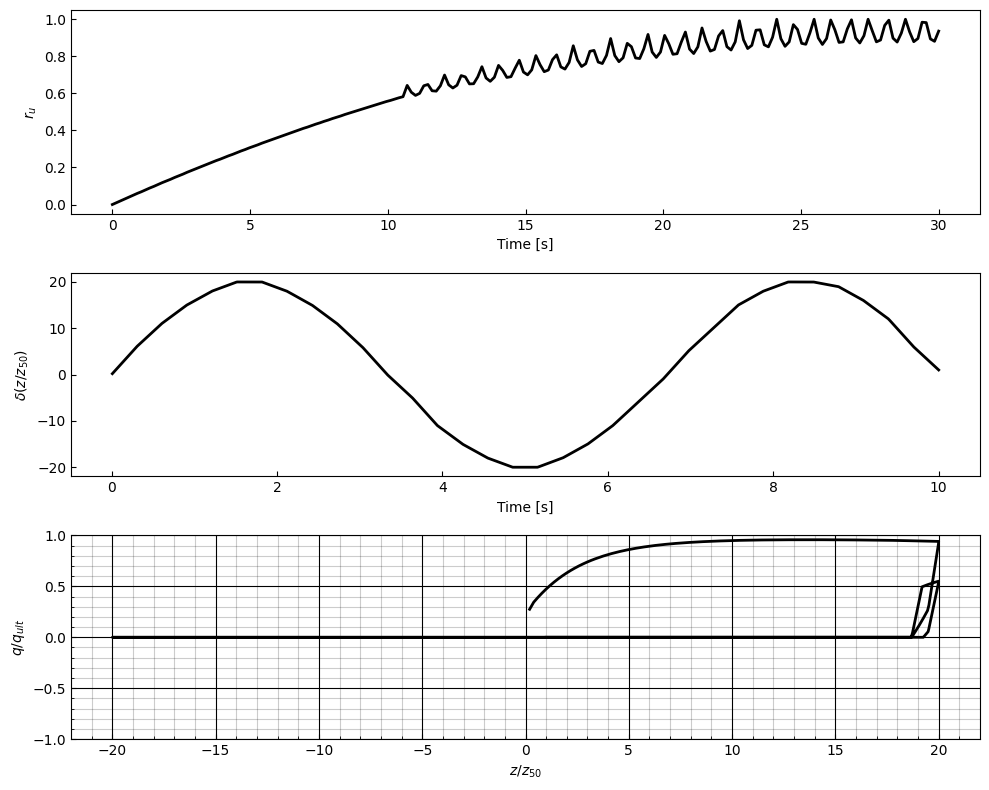

In [21]:
#################################################################
# Plot the results 
#################################################################
Node_Disp = np.loadtxt('Node_Disp_Liq.txt', delimiter=' '); 
QZ1 = np.loadtxt('QZ1_Liq.txt', delimiter=' '); 
Time = Node_Disp[:,0];
length = len(Time);

Figure=plt.figure(figsize=(10,8))
Ru_Axis = Figure.add_subplot(311);
U_Axis  = Figure.add_subplot(312);
QZ_Axis = Figure.add_subplot(313);

Ru_Axis.plot(MNS_Time,1-MeanStress,'-k',linewidth=2);
Ru_Axis.set_ylabel('$r_u $');
Ru_Axis.set_xlabel('Time [s]');

U_Axis.plot(Time,Node_Disp[:,1]/z50,'-k',linewidth=2);
U_Axis.set_ylabel('$\delta (z/z_{50})$');
U_Axis.set_xlabel('Time [s]');

QZ_Axis.plot(Node_Disp[:,1]/z50,QZ1[:,2]/qult,'-k',linewidth=2);
QZ_Axis.set_ylabel('$q/q_{ult}$ ');
QZ_Axis.set_xlabel('$z/z_{50}$');
QZ_Axis.set_ylim([-1,1])

plt.grid(visible=True, which='major', color='k', linestyle='-')
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='k', linestyle='-', alpha=0.2)
plt.tight_layout();
plt.savefig('Pile_Response_'+Analysis_Name+'.png', bbox_inches = 'tight', dpi = 800);
plt.show()
plt.close()

In [22]:
node_resp = opst.post.get_nodal_responses(odb_tag=333)
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-333.nc ...

<xarray.Dataset> Size: 300kB
Dimensions:             (time: 1001, nodeTags: 2, DOFs: 6)
Coordinates:
  * time                (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.98 9.99 10.0
  * nodeTags            (nodeTags) int64 16B 1 2
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 48kB 0.0 0.0 ... 0.0 0.0
    vel                 (time, nodeTags, DOFs) float32 48kB 0.0 0.0 ... 0.0 0.0
    accel               (time, nodeTags, DOFs) float32 48kB 0.0 0.0 ... 0.0 0.0
    reaction            (time, nodeTags, DOFs) float32 48kB 0.0 0.0 ... 0.0 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 48kB 0.0 0.0 ... 0.0 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 48kB 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 8kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Displacement 

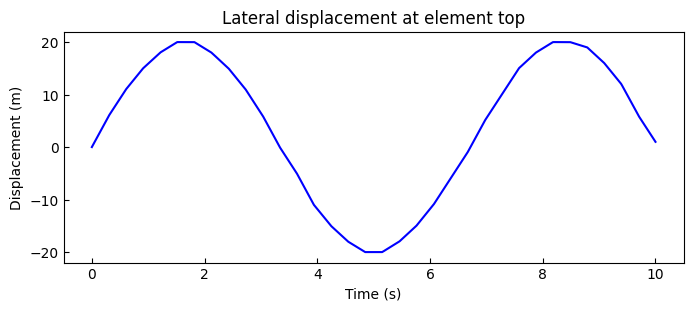

In [23]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UY")
#disp3 = node_resp["disp"].sel(nodeTags=1, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot( times,disp1 / z50,"b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

In [24]:
node_react = opst.post.get_nodal_responses(odb_tag=333, resp_type="reaction")
print(node_react)

OPSTOOL ::  Loading reaction response data from .opstool.output/RespStepData-333.nc ...

<xarray.DataArray 'reaction' (time: 1001, nodeTags: 2, DOFs: 6)> Size: 48kB
array([[[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00]],

       [[ 0.0000000e+00,  2.7479982e+01,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00, -2.7479982e+01,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00]],

       [[ 0.0000000e+00,  3.4437763e+01,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00, -3.4437763e+01,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00]],

       ...,

       [[ 0.0000000e+00, -1.1456547e-03,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  1.1456547e-03,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0

In [25]:
react_1 = node_react.sel(nodeTags=2, DOFs=["UY"])

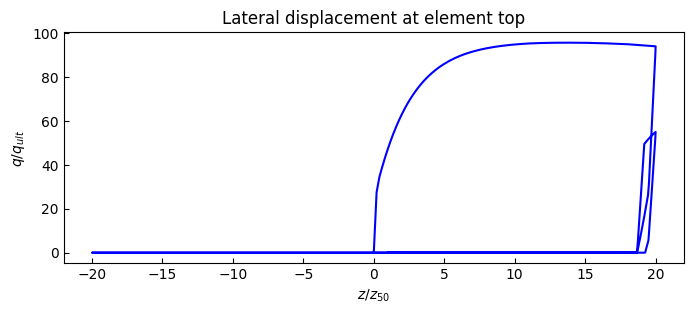

In [26]:
fig, QZ_Axis = plt.subplots(1, 1, figsize=(8, 3))
QZ_Axis.plot( disp1 / z50 , -react_1,"b")
QZ_Axis.set_title("Lateral displacement at element top")
QZ_Axis.set_ylabel('$q/q_{ult}$ ');
QZ_Axis.set_xlabel('$z/z_{50}$');
plt.show()